## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.31MB/s]


torch.Size([1, 28, 28])


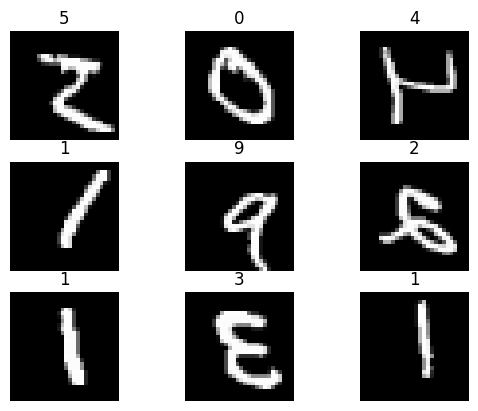

In [ ]:
# MNIST transform 정의
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),   # (주의) MNIST에선 보통 안 쓰지만 요청대로 유지
    transforms.RandomCrop(28, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# train dataset
train_data = datasets.MNIST(
    root="./data/",
    train=True,
    download=True,
    transform=train_transform
)

# test dataset
test_data = datasets.MNIST(
    root="./data/",
    train=False,
    download=True,
    transform=test_transform
)

# 시각화 (MNIST는 (1,28,28)이라 imshow에 맞게 squeeze 필요)
for i in range(9):
    plt.subplot(3, 3, i+1)
    img, label = train_data[i]   # transform 적용된 이미지
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(str(label))
    plt.axis("off")

print(train_data[0][0].shape)  # torch.Size([1, 28, 28])
plt.show()


In [ ]:
from torch.utils.data import Dataset

class CustomMNIST(Dataset):
    def __init__(self, root, train=True, download=False):
        self.base_dataset = datasets.MNIST(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomCrop(28, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

        self.test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx].numpy()  # (H, W) numpy
        label = self.base_dataset.targets[idx].item()

        if self.train:
            image = self.transform(image)
        else:
            image = self.test_transform(image)

        return image, label


# 인스턴스 생성
train_data = CustomMNIST(root='./data/', train=True, download=True)
test_data = CustomMNIST(root='./data/', train=False, download=True)

## Modeling

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [ ]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)  # 28x28 -> 14x14
        self.block2 = BasicBlock(in_channels=32, out_channels=64, hidden_dim=32) # 14x14 -> 7x7

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [ ]:
class CNN_MNIST(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN_MNIST, self).__init__()

        # MNIST는 흑백이므로 in_channels=1
        self.block1 = BasicBlock(in_channels=1, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # MNIST: 최종 feature map 크기 = (256, 3, 3) -> 2304
        self.fc1 = nn.Linear(in_features=256 * 3 * 3, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)  # 출력: (-1, 256, 3, 3)

        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [ ]:
from torch.utils.data.dataloader import DataLoader
from torch.optim.adam import Adam
import torch

# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device 정보: {device}")

# MNIST용 CNN 모델 정의
model = CNN_MNIST(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cuda


CNN_MNIST(
  (block1): BasicBlock(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_feature

In [ ]:
import copy
import torch
import torch.nn as nn
from torch.optim.adam import Adam
from tqdm import tqdm

# Learning rate
lr = 1e-3

# Optimizer / Loss
optim = Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# ===== Early Stopping (공격적으로) =====
max_epochs = 20
patience = 3
min_delta = 1e-3   # val loss가 최소 이만큼 좋아져야 "개선"으로 인정

best_val_loss = float("inf")
patience_counter = 0
best_state = None

for epoch in range(max_epochs):
    # ===== Train =====
    model.train()
    for data, label in tqdm(train_loader, desc=f"Train {epoch+1}/{max_epochs}"):
        data = data.to(device)
        label = label.to(device)

        optim.zero_grad()
        preds = model(data)
        loss = criterion(preds, label)
        loss.backward()
        optim.step()

    # ===== Validation (여기서는 test_loader를 val로 사용) =====
    model.eval()
    running_val_loss = 0.0
    val_n = 0

    with torch.no_grad():
        for data, label in test_loader:
            data = data.to(device)
            label = label.to(device)

            preds = model(data)
            vloss = criterion(preds, label)

            running_val_loss += vloss.item() * data.size(0)
            val_n += data.size(0)

    val_loss = running_val_loss / val_n

    # 로그 (매 epoch 출력)
    print(f"epoch {epoch+1} | train loss: {loss.item():.4f} | val loss: {val_loss:.4f}")

    # ===== Early Stopping 체크 =====
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping! (epoch {epoch+1}, best val loss: {best_val_loss:.4f})")
            break

# best model로 복원 후 저장
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "MNIST.pth")
print("Saved best model to MNIST.pth")


Train 1/20: 100%|██████████| 938/938 [00:27<00:00, 34.56it/s]


epoch 1 | train loss: 0.0400 | val loss: 0.1839


Train 2/20: 100%|██████████| 938/938 [00:25<00:00, 36.52it/s]


epoch 2 | train loss: 0.1135 | val loss: 0.0801


Train 3/20: 100%|██████████| 938/938 [00:27<00:00, 34.08it/s]


...

epoch 8 | train loss: 0.0156 | val loss: 0.0623


Train 9/20: 100%|██████████| 938/938 [00:25<00:00, 36.31it/s]


epoch 9 | train loss: 0.2051 | val loss: 0.0735


Train 10/20: 100%|██████████| 938/938 [00:25<00:00, 36.29it/s]


epoch 10 | train loss: 0.0007 | val loss: 0.0517
Early stopping! (epoch 10, best val loss: 0.0409)
Saved best model to MNIST.pth


In [ ]:
# MNIST 모델 불러오기
model.load_state_dict(torch.load("MNIST.pth", map_location=device))
model.to(device)
model.eval()

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        data = data.to(device)
        label = label.to(device)

        output = model(data)
        preds = output.argmax(dim=1)

        num_corr += (preds == label).sum().item()

print(f"Accuracy: {num_corr / len(test_data):.4f}")

100%|██████████| 157/157 [00:01<00:00, 86.71it/s]

Accuracy: 0.9862
